## 0 · Imports, Configuration & Data Loading

In [1]:
import os, time, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Input, GlobalAveragePooling2D,
    LSTM, GRU, SimpleRNN, Bidirectional,
    Conv2D, MaxPooling2D, BatchNormalization,
    Reshape, Embedding, LayerNormalization,
    GlobalAveragePooling1D, MultiHeadAttention, Add
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


DATASET_PATH = '/kaggle/input/datasets/s1dharthsna1r/dl-data'

IMG_H, IMG_W = 155, 154          
IMG_SIZE     = 224               
NUM_CLASSES  = 5
BATCH_SIZE   = 32
SEED         = 42
LABEL_MAP    = {
    0: 'Normal (N)',
    1: 'Supraventricular (S)',
    2: 'Ventricular (V)',
    3: 'Fusion (F)',
    4: 'Unknown (Q)'
}

tf.random.set_seed(SEED)
np.random.seed(SEED)


2026-03-07 04:04:44.676841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772856284.882830      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772856284.945423      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772856285.420610      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772856285.420657      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772856285.420660      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
ZIP_CANDIDATES = [f for f in os.listdir(DATASET_PATH)
                  if f.endswith('.zip')] if os.path.isdir(DATASET_PATH) else []

EXTRACT_DIR = '/kaggle/working/cwt_images'

if ZIP_CANDIDATES:
    zip_path = os.path.join(DATASET_PATH, ZIP_CANDIDATES[0])
    print(f"Extracting {zip_path} → {EXTRACT_DIR}")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Extraction complete")
else:
    
    EXTRACT_DIR = DATASET_PATH
    print(f"Using dataset directly from {EXTRACT_DIR}")

class_folders = sorted([
    d for d in os.listdir(EXTRACT_DIR)
    if os.path.isdir(os.path.join(EXTRACT_DIR, d))
])
print("\nClass folders found:", class_folders)
for cf in class_folders:
    n = len(os.listdir(os.path.join(EXTRACT_DIR, cf)))
    print(f"  Class {cf}: {n} images")


Using dataset directly from /kaggle/input/datasets/s1dharthsna1r/dl-data

Class folders found: ['0.0', '1.0', '2.0', '3.0', '4.0']
  Class 0.0: 6000 images
  Class 1.0: 2223 images
  Class 2.0: 5788 images
  Class 3.0: 641 images
  Class 4.0: 6431 images


In [3]:
filepaths, labels = [], []

_all_dirs = sorted([
    d for d in os.listdir(EXTRACT_DIR)
    if os.path.isdir(os.path.join(EXTRACT_DIR, d))
])
def find_class_folder(base, class_id):
    for candidate in [str(class_id), f"{class_id}.0", f"{float(class_id)}", f"{class_id:02d}"]:
        path = os.path.join(base, candidate)
        if os.path.isdir(path):
            return path
    return None

for class_id in range(NUM_CLASSES):
    folder = find_class_folder(EXTRACT_DIR, class_id)
    if folder is None:
        print(f"Warning: folder for class {class_id} not found in {EXTRACT_DIR}")
        continue
    count = 0
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepaths.append(os.path.join(folder, fname))
            labels.append(class_id)
            count += 1
    print(f"  Class {class_id} ({os.path.basename(folder)}): {count} images")

filepaths = np.array(filepaths)
labels    = np.array(labels, dtype=np.int32)

print(f"Total images : {len(filepaths)}")
print("Per-class    :", dict(zip(*np.unique(labels, return_counts=True))))



# Train / Val / Test split  (70 / 15 / 15)
from sklearn.model_selection import train_test_split
fp_tr, fp_tmp, y_tr, y_tmp = train_test_split(
    filepaths, labels, test_size=0.30, random_state=SEED, stratify=labels)
fp_val, fp_te, y_val, y_te = train_test_split(
    fp_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f"Train: {len(fp_tr)}  Val: {len(fp_val)}  Test: {len(fp_te)}")



# Class weights
cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_tr)
class_weights = dict(enumerate(cw_arr))
print("Class weights:", {k: round(v,2) for k,v in class_weights.items()})


  Class 0 (0.0): 6000 images
  Class 1 (1.0): 2223 images
  Class 2 (2.0): 5788 images
  Class 3 (3.0): 641 images
  Class 4 (4.0): 6431 images
Total images : 21083
Per-class    : {np.int32(0): np.int64(6000), np.int32(1): np.int64(2223), np.int32(2): np.int64(5788), np.int32(3): np.int64(641), np.int32(4): np.int64(6431)}
Train: 14758  Val: 3162  Test: 3163
Class weights: {0: np.float64(0.7), 1: np.float64(1.9), 2: np.float64(0.73), 3: np.float64(6.57), 4: np.float64(0.66)}


In [5]:
def load_and_preprocess(path, label, img_size=IMG_SIZE):
    """Read PNG → resize → normalise [0,1]."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [img_size, img_size])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    """Light augmentation for training set only."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

def make_dataset(fps, ys, training=False, batch=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((fps, ys))
    ds = ds.map(load_and_preprocess,
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(fp_tr,  y_tr,  training=True)
val_ds   = make_dataset(fp_val, y_val, training=False)
test_ds  = make_dataset(fp_te,  y_te,  training=False)

print("Datasets ready ✓")
print(f"  Batches – Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")


Datasets ready ✓
  Batches – Train: 462  Val: 99  Test: 99


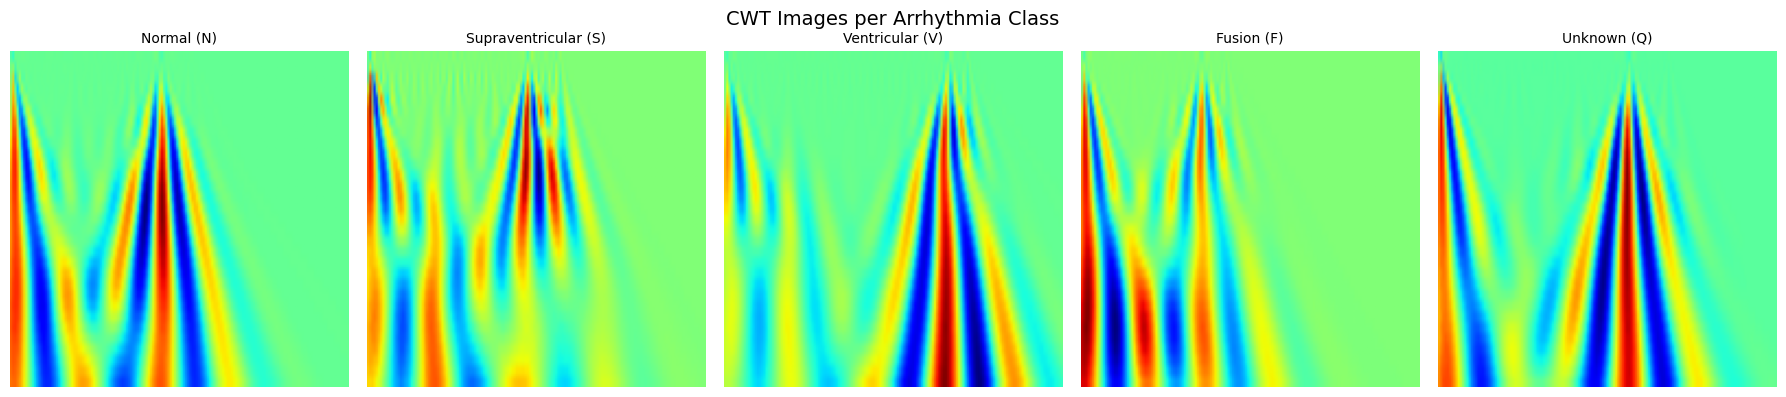

In [6]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))
fig.suptitle('CWT Images per Arrhythmia Class', fontsize=14)

for cls in range(NUM_CLASSES):
    idx  = np.where(labels == cls)[0][0]
    img  = plt.imread(filepaths[idx])
    axes[cls].imshow(img)
    axes[cls].set_title(LABEL_MAP[cls], fontsize=10)
    axes[cls].axis('off')

plt.tight_layout(); plt.show()


## 1 · Feature Extraction using Pretrained CNN Models 



In [7]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1)

lr_reduce = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, verbose=1)


def build_frozen_extractor(backbone_fn, name, img_size=IMG_SIZE):
    
    base = backbone_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = False      

    inputs = Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name=name)
    model.compile(
        optimizer=Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"{name} – trainable params: {model.count_params():,}")
    return model


In [8]:
resnet_ext = build_frozen_extractor(ResNet50, 'ResNet50_Extractor')

print("\n── Training ResNet50 Feature Extractor ──")
t0 = time.time()
hist_resnet_ext = resnet_ext.fit(
    train_ds, validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)
print(f"Training time: {time.time()-t0:.1f}s")
resnet_ext_acc = resnet_ext.evaluate(test_ds, verbose=0)[1]
print(f"ResNet50 Extractor – Test Accuracy: {resnet_ext_acc:.4f}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50_Extractor – trainable params: 24,771,461

── Training ResNet50 Feature Extractor ──
Epoch 1/25


I0000 00:00:1772857027.549604     124 service.cc:152] XLA service 0x7b5898113880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772857027.549646     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772857029.803869     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


  4/462 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.2077 - loss: 1.6455 

I0000 00:00:1772857035.098133     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


462/462 ━━━━━━━━━━━━━━━━━━━━ 61s 92ms/step - accuracy: 0.5983 - loss: 1.0376 - val_accuracy: 0.2846 - val_loss: 6.1113 - learning_rate: 0.0010
Epoch 2/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.7041 - loss: 0.7755 - val_accuracy: 0.3672 - val_loss: 2.8026 - learning_rate: 0.0010
Epoch 3/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.7342 - loss: 0.7019 - val_accuracy: 0.2612 - val_loss: 7.1181 - learning_rate: 0.0010
Epoch 4/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.7481 - loss: 0.6529 - val_accuracy: 0.3172 - val_loss: 4.1190 - learning_rate: 0.0010
Epoch 5/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.7608 - loss: 0.6255 - val_accuracy: 0.3552 - val_loss: 2.6377 - learning_rate: 0.0010
Epoch 6/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.7686 - loss: 0.6127 - val_accuracy: 0.2027 - val_loss: 6.8874 - learning_rate: 0.0010
Epoch 7/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.7797 - loss: 0.5911

In [9]:
vgg_ext = build_frozen_extractor(VGG16, 'VGG16_Extractor')

print("\n── Training VGG16 Feature Extractor ──")
t0 = time.time()
hist_vgg_ext = vgg_ext.fit(
    train_ds, validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)
print(f"Training time: {time.time()-t0:.1f}s")
vgg_ext_acc = vgg_ext.evaluate(test_ds, verbose=0)[1]
print(f"VGG16 Extractor – Test Accuracy: {vgg_ext_acc:.4f}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16_Extractor – trainable params: 15,112,005

── Training VGG16 Feature Extractor ──
Epoch 1/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 66s 113ms/step - accuracy: 0.7058 - loss: 0.8364 - val_accuracy: 0.7982 - val_loss: 0.5508 - learning_rate: 0.0010
Epoch 2/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - accuracy: 0.8165 - loss: 0.5389 - val_accuracy: 0.6293 - val_loss: 1.0661 - learning_rate: 0.0010
Epoch 3/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 44s 91ms/step - accuracy: 0.8407 - loss: 0.4628 - val_accuracy: 0.7378 - val_loss: 0.8052 - learning_rate: 0.0010
Epoch 4/25
461/462 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8485 - loss: 0.4405
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
462/462 ━━━━━━━━━━━━━━━━━━━━ 44s 91ms/step - accuracy: 0.8485 - loss: 0.4404 - val_accuracy: 0.7976 - val_loss: 0.5889 - learning_rate: 0.0010
Epoch 5/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - accuracy: 0.8629 - loss: 0.4028 - val

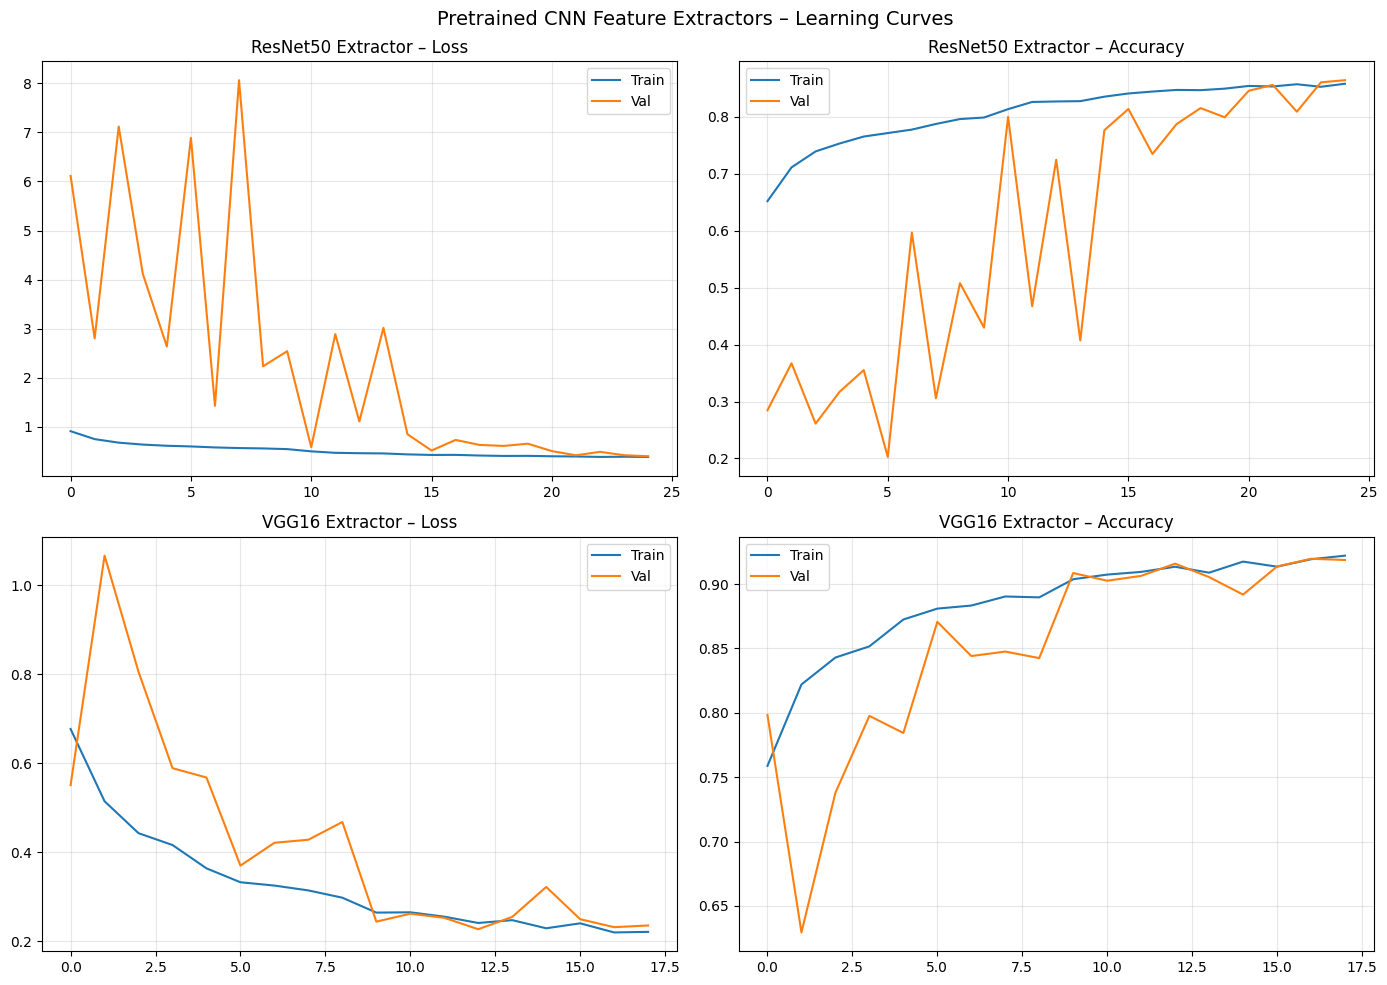

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pretrained CNN Feature Extractors – Learning Curves', fontsize=14)

for row, (name, hist) in enumerate([
        ('ResNet50 Extractor', hist_resnet_ext),
        ('VGG16 Extractor',    hist_vgg_ext)]):
    axes[row,0].plot(hist.history['loss'],         label='Train')
    axes[row,0].plot(hist.history['val_loss'],     label='Val')
    axes[row,0].set_title(f'{name} – Loss')
    axes[row,0].legend(); axes[row,0].grid(alpha=0.3)

    axes[row,1].plot(hist.history['accuracy'],     label='Train')
    axes[row,1].plot(hist.history['val_accuracy'], label='Val')
    axes[row,1].set_title(f'{name} – Accuracy')
    axes[row,1].legend(); axes[row,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 2 · Fine-tuning Pretrained CNN – ResNet50



In [11]:
def build_resnet_finetune(img_size=IMG_SIZE):
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(img_size, img_size, 3))
    base.trainable = False         

    inputs  = Input(shape=(img_size, img_size, 3))
    x       = base(inputs, training=False)
    x       = GlobalAveragePooling2D()(x)
    x       = Dense(512, activation='relu')(x)
    x       = BatchNormalization()(x)
    x       = Dropout(0.4)(x)
    x       = Dense(256, activation='relu')(x)
    x       = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name='ResNet50_FineTuned')
    return model, base         
resnet_ft_model, resnet_base = build_resnet_finetune()

print("── Phase 1: Training head (backbone frozen) ──")
resnet_ft_model.compile(optimizer=Adam(1e-3),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])
resnet_ft_model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)


── Phase 1: Training head (backbone frozen) ──
Epoch 1/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 55s 85ms/step - accuracy: 0.5934 - loss: 1.0550 - val_accuracy: 0.3276 - val_loss: 3.3527
Epoch 2/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.6960 - loss: 0.7883 - val_accuracy: 0.2891 - val_loss: 9.1139
Epoch 3/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.7304 - loss: 0.7046 - val_accuracy: 0.2884 - val_loss: 4.8211
Epoch 4/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.7477 - loss: 0.6747 - val_accuracy: 0.3229 - val_loss: 7.6305


In [12]:
print("\n── Phase 2: Fine-tuning last 30 ResNet50 layers ──")
resnet_base.trainable = True
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in resnet_base.layers if l.trainable)
print(f"Unfrozen ResNet50 layers: {trainable_count} / {len(resnet_base.layers)}")

resnet_ft_model.compile(
    optimizer=Adam(1e-5),           
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
hist_resnet_ft = resnet_ft_model.fit(
    train_ds, validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)
print(f"Phase 2 time: {time.time()-t0:.1f}s")

resnet_ft_acc = resnet_ft_model.evaluate(test_ds, verbose=0)[1]
print(f"\nResNet50 Fine-tuned  – Test Accuracy : {resnet_ft_acc:.4f}")
print(f"ResNet50 Extractor   – Test Accuracy : {resnet_ext_acc:.4f}")
print(f"Fine-tuning gain     : {resnet_ft_acc - resnet_ext_acc:+.4f}")



── Phase 2: Fine-tuning last 30 ResNet50 layers ──
Unfrozen ResNet50 layers: 30 / 175
Epoch 1/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 75s 112ms/step - accuracy: 0.6585 - loss: 0.9597 - val_accuracy: 0.8153 - val_loss: 0.4848 - learning_rate: 1.0000e-05
Epoch 2/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.7596 - loss: 0.6337 - val_accuracy: 0.8514 - val_loss: 0.4095 - learning_rate: 1.0000e-05
Epoch 3/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.7879 - loss: 0.5741 - val_accuracy: 0.8501 - val_loss: 0.4209 - learning_rate: 1.0000e-05
Epoch 4/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.8031 - loss: 0.5366 - val_accuracy: 0.8488 - val_loss: 0.4331 - learning_rate: 1.0000e-05
Epoch 5/30
461/462 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8198 - loss: 0.4994
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
462/462 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - accuracy: 0.8198 - loss: 0.4994 - val_accuracy: 0.8090 - val_loss: 0.577

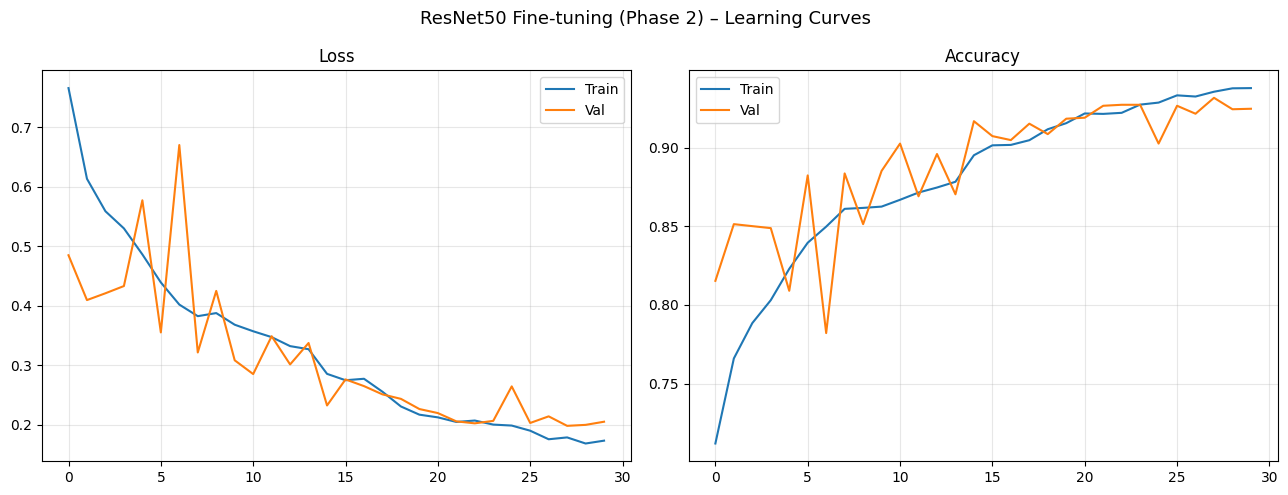

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ResNet50 Fine-tuning (Phase 2) – Learning Curves', fontsize=13)

ax1.plot(hist_resnet_ft.history['loss'],         label='Train')
ax1.plot(hist_resnet_ft.history['val_loss'],     label='Val')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_resnet_ft.history['accuracy'],     label='Train')
ax2.plot(hist_resnet_ft.history['val_accuracy'], label='Val')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 3 · Temporal Data Preprocessing Pipeline 
```
CWT image (224×224×3)
    → ResNet50 backbone (no head)    → feature map (7×7×2048)
    → Reshape columns as time steps  → (7 steps × 7×2048 features)
    → GlobalAvgPool per step         → (7 steps × 2048)
    → Feed to RNN / LSTM / GRU
```


In [14]:
_base_for_features = ResNet50(
    weights=None,                        
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling=None
)
_ft_backbone = resnet_ft_model.get_layer("resnet50")
_base_for_features.set_weights(_ft_backbone.get_weights())
_base_for_features.trainable = False

feature_extractor = _base_for_features 
print("Feature extractor output shape:", feature_extractor.output_shape)

def extract_temporal_features(dataset, extractor):
    
    all_feats, all_labels = [], []
    for imgs, ys in dataset:
        fmap = extractor(imgs, training=False)        
        seq  = tf.reduce_mean(fmap, axis=1)           
        all_feats.append(seq.numpy())
        all_labels.append(ys.numpy())
    X = np.concatenate(all_feats,  axis=0)
    y = np.concatenate(all_labels, axis=0)
    return X.astype("float32"), y


print("Extracting temporal features from train set …")
t0 = time.time()
X_seq_tr,  y_seq_tr  = extract_temporal_features(train_ds,  feature_extractor)
X_seq_val, y_seq_val = extract_temporal_features(val_ds,    feature_extractor)
X_seq_te,  y_seq_te  = extract_temporal_features(test_ds,   feature_extractor)
print(f"Done in {time.time()-t0:.1f}s")

print(f"Temporal sequence shapes:")
print(f"  Train : {X_seq_tr.shape}   → (samples, time_steps, features)")
print(f"  Val   : {X_seq_val.shape}")
print(f"  Test  : {X_seq_te.shape}")

TIME_STEPS = X_seq_tr.shape[1]   
FEAT_DIM   = X_seq_tr.shape[2]   


Feature extractor output shape: (None, 7, 7, 2048)
Extracting temporal features from train set …
Done in 166.4s
Temporal sequence shapes:
  Train : (14758, 7, 2048)   → (samples, time_steps, features)
  Val   : (3162, 7, 2048)
  Test  : (3163, 7, 2048)


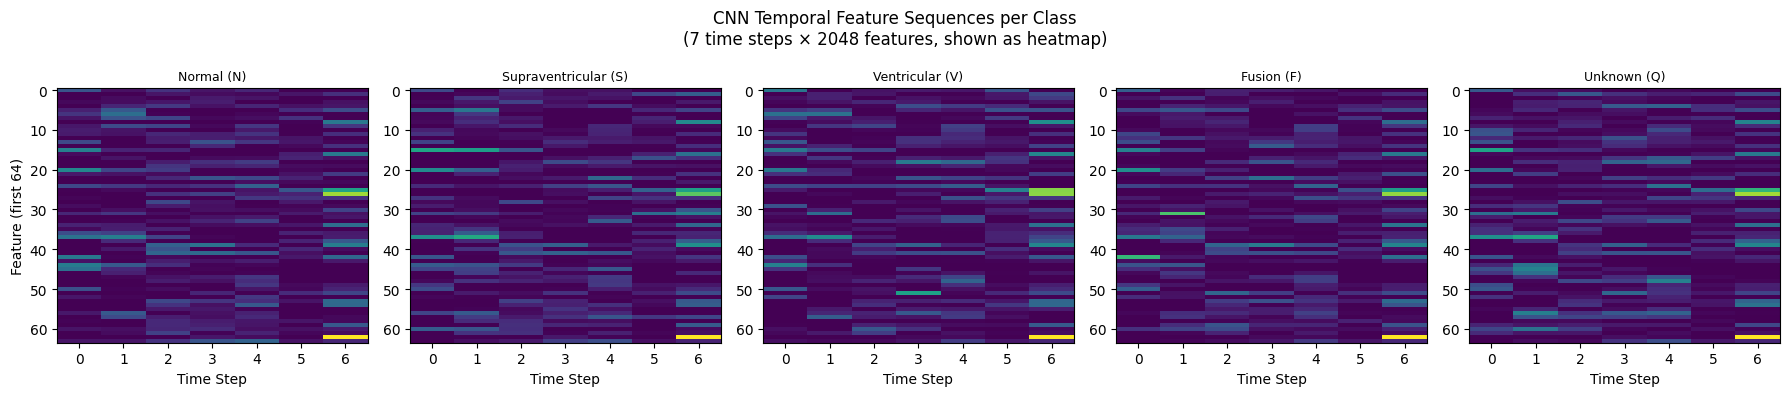

In [15]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))
fig.suptitle('CNN Temporal Feature Sequences per Class\n(7 time steps × 2048 features, shown as heatmap)',
             fontsize=12)

for cls in range(NUM_CLASSES):
    idx = np.where(y_seq_tr == cls)[0][0]
    axes[cls].imshow(X_seq_tr[idx, :, :64].T, aspect='auto',
                     cmap='viridis', interpolation='nearest')
    axes[cls].set_title(LABEL_MAP[cls], fontsize=9)
    axes[cls].set_xlabel('Time Step')
    if cls == 0: axes[cls].set_ylabel('Feature (first 64)')

plt.tight_layout(); plt.show()


## 4 · Embedding Usage 


In [16]:
PATCH_SIZE  = 16
N_PATCHES   = (IMG_SIZE // PATCH_SIZE) ** 2   
PATCH_DIM   = PATCH_SIZE * PATCH_SIZE * 3     
EMBED_DIM   = 128                             

def extract_patches(images):
   
    B = tf.shape(images)[0]
    patches = tf.image.extract_patches(
        images=images,
        sizes=[1, PATCH_SIZE, PATCH_SIZE, 1],
        strides=[1, PATCH_SIZE, PATCH_SIZE, 1],
        rates=[1, 1, 1, 1],
        padding='VALID'
    )
    patches = tf.reshape(patches, [B, N_PATCHES, PATCH_DIM])
    return tf.cast(patches, tf.float32)


def build_patch_embed_lstm(n_patches=N_PATCHES, patch_dim=PATCH_DIM,
                           embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                           lr=1e-3):
    
    inputs  = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')

    patches = layers.Lambda(extract_patches, name='patch_extractor')(inputs)

    x = Dense(embed_dim, use_bias=False, name='patch_embedding')(patches)

    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = LSTM(64)(x)
    x = Dropout(0.3)(x)

    x       = Dense(128, activation='relu')(x)
    x       = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='PatchEmbed_LSTM')
    model.compile(optimizer=Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

embed_model = build_patch_embed_lstm()
embed_model.summary()
print(f"\nPatch Embedding layer shape: ({N_PATCHES} patches, {EMBED_DIM}-dim embeddings)")


Model: "PatchEmbed_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_extractor (Lambda)        │ (None, 196, 768)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding (Dense)         │ (None, 196, 128)       │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 196, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 196, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,261 (1.10 MB)

 Trainable params: 288,261 (1.10 MB)

 Non-trainable params: 0 (0.00 B)


Patch Embedding layer shape: (196 patches, 128-dim embeddings)


In [17]:
print("\n── Training Patch Embedding + LSTM ──")
t0 = time.time()
hist_embed = embed_model.fit(
    train_ds, validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, lr_reduce]
)
print(f"Training time: {time.time()-t0:.1f}s")
embed_acc = embed_model.evaluate(test_ds, verbose=0)[1]
print(f"Patch Embed + LSTM – Test Accuracy: {embed_acc:.4f}")



── Training Patch Embedding + LSTM ──
Epoch 1/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.2169 - loss: 1.6257 - val_accuracy: 0.0867 - val_loss: 1.6899 - learning_rate: 0.0010
Epoch 2/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.2700 - loss: 1.5006 - val_accuracy: 0.3112 - val_loss: 1.5031 - learning_rate: 0.0010
Epoch 3/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.3532 - loss: 1.3537 - val_accuracy: 0.4658 - val_loss: 1.2393 - learning_rate: 0.0010
Epoch 4/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.5071 - loss: 1.1597 - val_accuracy: 0.5582 - val_loss: 1.0894 - learning_rate: 0.0010
Epoch 5/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.5866 - loss: 1.0329 - val_accuracy: 0.6964 - val_loss: 0.8148 - learning_rate: 0.0010
Epoch 6/30
462/462 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.6489 - loss: 0.9233 - val_accuracy: 0.7290 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 7/30
462/462 ━━━━━━━━━━━━━━━━━━

## 5 · RNN / LSTM / GRU Implementation 

In [18]:
def build_simple_rnn(time_steps=TIME_STEPS, feat_dim=FEAT_DIM,
                     num_classes=NUM_CLASSES, units=128, lr=1e-3):
    model = Sequential([
        Input(shape=(time_steps, feat_dim)),
        SimpleRNN(units, return_sequences=True, activation='tanh'),
        Dropout(0.3),
        SimpleRNN(units // 2, activation='tanh'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='SimpleRNN')
    model.compile(optimizer=Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def build_stacked_lstm(time_steps=TIME_STEPS, feat_dim=FEAT_DIM,
                       num_classes=NUM_CLASSES, units=128, lr=1e-3):
    model = Sequential([
        Input(shape=(time_steps, feat_dim)),
        LSTM(units, return_sequences=True),
        Dropout(0.3),
        LSTM(units // 2),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='StackedLSTM')
    model.compile(optimizer=Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def build_stacked_gru(time_steps=TIME_STEPS, feat_dim=FEAT_DIM,
                      num_classes=NUM_CLASSES, units=128, lr=1e-3):
    model = Sequential([
        Input(shape=(time_steps, feat_dim)),
        GRU(units, return_sequences=True),
        Dropout(0.3),
        GRU(units // 2),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='StackedGRU')
    model.compile(optimizer=Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

for fn in [build_simple_rnn, build_stacked_lstm, build_stacked_gru]:
    m = fn()
    print(f"{m.name:20s}  params: {m.count_params():,}")


SimpleRNN             params: 299,973
StackedLSTM           params: 1,172,997
StackedGRU            params: 882,565


In [20]:
seq_results = {}

for name, build_fn in [
    ('SimpleRNN',   build_simple_rnn),
    ('StackedLSTM', build_stacked_lstm),
    ('StackedGRU',  build_stacked_gru)
]:
    print(f"\n{'='*55}")
    print(f"  Training  {name}")
    print('='*55)

    es = callbacks.EarlyStopping(
        monitor='val_loss', patience=6,
        restore_best_weights=True, verbose=0)
    rl = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=0)

    m = build_fn()
    t0 = time.time()
    h  = m.fit(
        X_seq_tr, y_seq_tr,
        validation_data=(X_seq_val, y_seq_val),
        epochs=50, batch_size=64,
        class_weight=class_weights,
        callbacks=[es, rl], verbose=1
    )
    elapsed = time.time() - t0
    acc = m.evaluate(X_seq_te, y_seq_te, verbose=0)[1]
    print(f" Test Accuracy: {acc:.4f}  |  Time: {elapsed:.1f}s")
    seq_results[name] = {'model': m, 'history': h, 'acc': acc}



  Training  SimpleRNN
Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3802 - loss: 1.3569 - val_accuracy: 0.7793 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7881 - loss: 0.5657 - val_accuracy: 0.8779 - val_loss: 0.4615 - learning_rate: 0.0010
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8442 - loss: 0.4612 - val_accuracy: 0.8824 - val_loss: 0.4153 - learning_rate: 0.0010
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8612 - loss: 0.4063 - val_accuracy: 0.8918 - val_loss: 0.3769 - learning_rate: 0.0010
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8794 - loss: 0.3551 - val_accuracy: 0.9035 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8847 - loss: 0.3553 - val_accuracy: 0.8817 - val_loss: 0.4234 - learning_rate: 0.0010
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy:

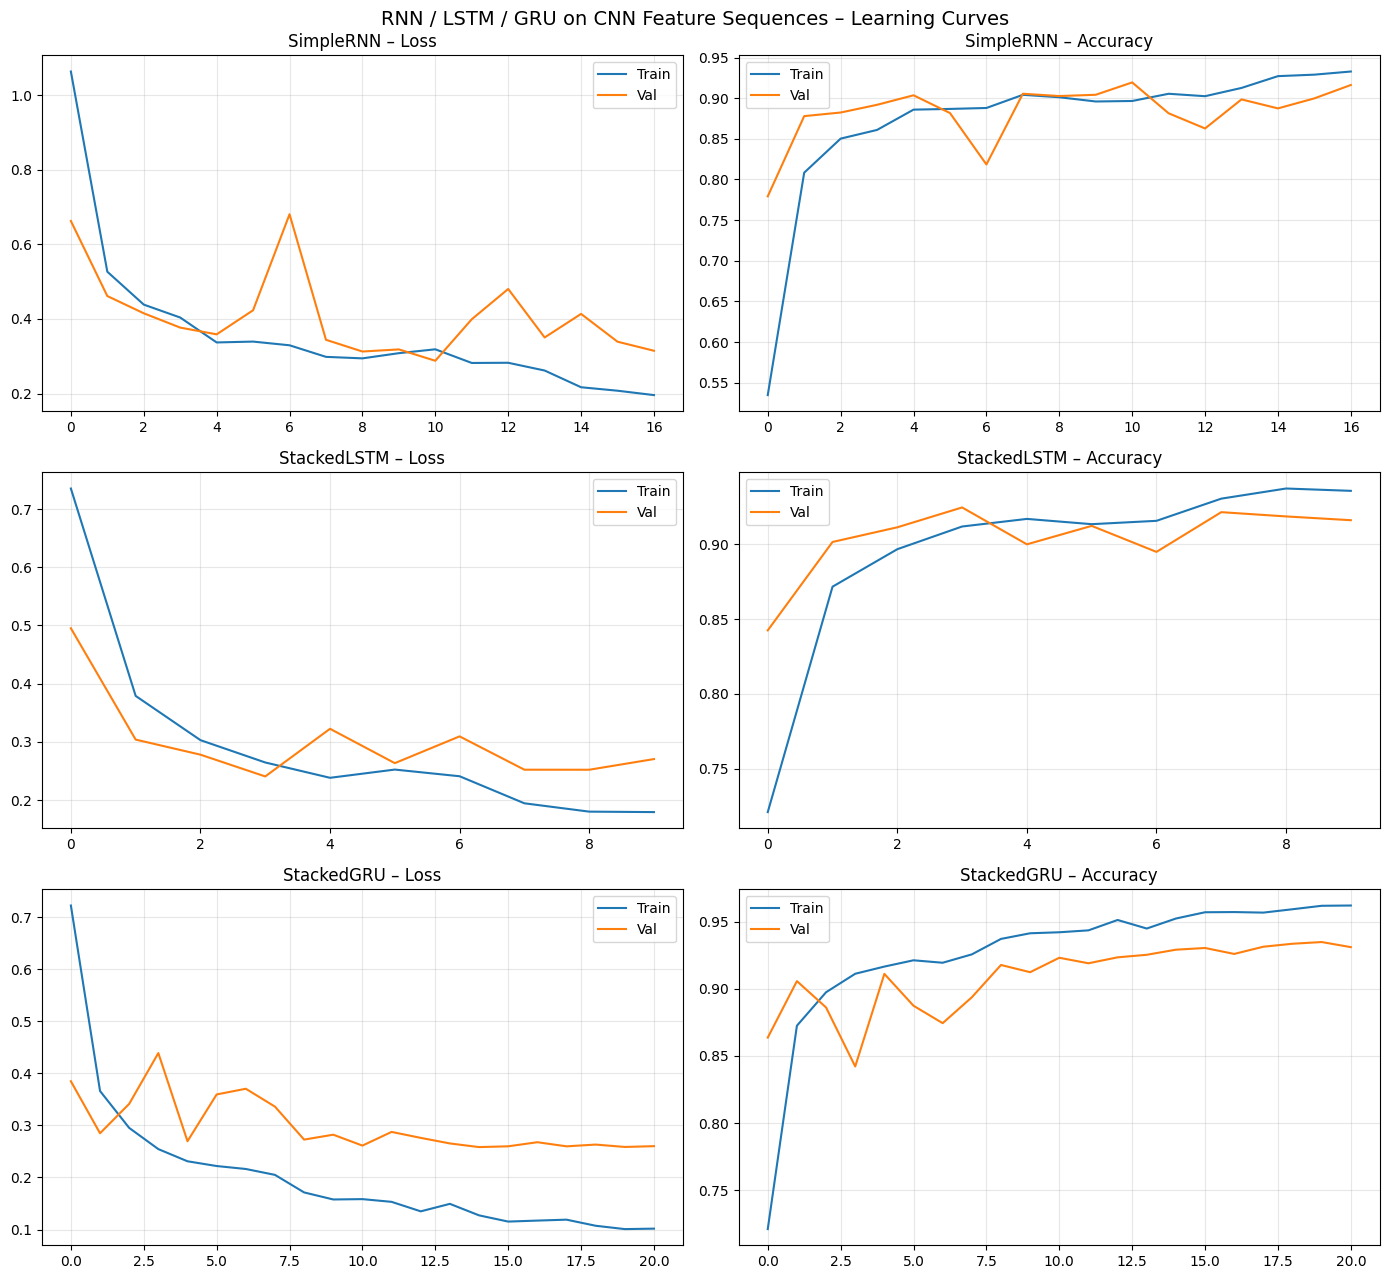

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle('RNN / LSTM / GRU on CNN Feature Sequences – Learning Curves', fontsize=14)

for row, name in enumerate(['SimpleRNN', 'StackedLSTM', 'StackedGRU']):
    h = seq_results[name]['history']
    axes[row,0].plot(h.history['loss'],         label='Train')
    axes[row,0].plot(h.history['val_loss'],     label='Val')
    axes[row,0].set_title(f'{name} – Loss')
    axes[row,0].legend(); axes[row,0].grid(alpha=0.3)

    axes[row,1].plot(h.history['accuracy'],     label='Train')
    axes[row,1].plot(h.history['val_accuracy'], label='Val')
    axes[row,1].set_title(f'{name} – Accuracy')
    axes[row,1].legend(); axes[row,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 6 · Attention-Based Model 


In [22]:
class BahdanauAttention(layers.Layer):
   
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = Dense(units, use_bias=False)
        self.V = Dense(1,     use_bias=False)

    def call(self, encoder_out):
        score   = self.V(tf.nn.tanh(self.W(encoder_out)))  
        weights = tf.nn.softmax(score, axis=1)             
        context = tf.reduce_sum(weights * encoder_out, axis=1) 
        return context, tf.squeeze(weights, -1)


def build_attention_lstm(time_steps=TIME_STEPS, feat_dim=FEAT_DIM,
                         num_classes=NUM_CLASSES, units=128, lr=1e-3):
    inputs   = Input(shape=(time_steps, feat_dim), name='seq_input')
    lstm_out = LSTM(units, return_sequences=True, name='lstm_encoder')(inputs)
    lstm_out = Dropout(0.3)(lstm_out)
    context, attn_w = BahdanauAttention(units, name='bahdanau_attention')(lstm_out)
    x        = Dense(128, activation='relu')(context)
    x        = Dropout(0.3)(x)
    outputs  = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='LSTM_Attention')
    model.compile(optimizer=Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

attn_model = build_attention_lstm()
attn_model.summary()


Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ seq_input (InputLayer)          │ (None, 7, 2048)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_encoder (LSTM)             │ (None, 7, 128)         │     1,114,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention              │ [(None, 128), (None,   │        16,512 │
│ (BahdanauAttention)             │ 7)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,293 (4.38 MB)

 Trainable params: 1,148,293 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print("\n── Training LSTM + Bahdanau Attention ──")
es_attn = callbacks.EarlyStopping(
    monitor='val_loss', patience=6,
    restore_best_weights=True, verbose=1)

t0 = time.time()
hist_attn = attn_model.fit(
    X_seq_tr, y_seq_tr,
    validation_data=(X_seq_val, y_seq_val),
    epochs=50, batch_size=64,
    class_weight=class_weights,
    callbacks=[es_attn, lr_reduce]
)
print(f"Training time: {time.time()-t0:.1f}s")
attn_acc = attn_model.evaluate(X_seq_te, y_seq_te, verbose=0)[1]
print(f"LSTM + Attention – Test Accuracy: {attn_acc:.4f}")



── Training LSTM + Bahdanau Attention ──
Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5909 - loss: 1.0334 - val_accuracy: 0.8997 - val_loss: 0.3184 - learning_rate: 0.0010
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8683 - loss: 0.3806 - val_accuracy: 0.9149 - val_loss: 0.2656 - learning_rate: 0.0010
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8953 - loss: 0.3123 - val_accuracy: 0.9146 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9090 - loss: 0.2719 - val_accuracy: 0.9187 - val_loss: 0.2271 - learning_rate: 0.0010
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9121 - loss: 0.2507 - val_accuracy: 0.9127 - val_loss: 0.2648 - learning_rate: 0.0010
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9159 - loss: 0.2303 - val_accuracy: 0.9032 - val_loss: 0.2818 - learning_rate: 0.0010
Epoch 7/50
229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 7m

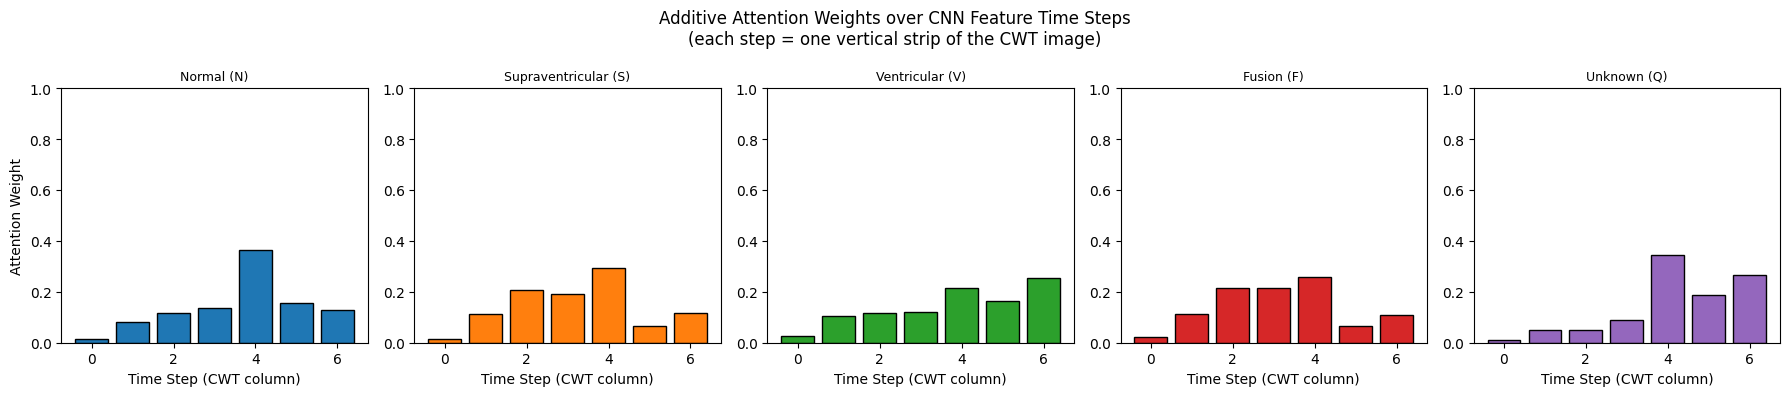

In [24]:

attn_visualiser = Model(
    inputs  = attn_model.input,
    outputs = [attn_model.output,
               attn_model.get_layer('bahdanau_attention').output[1]]
)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))
fig.suptitle(
    'Additive Attention Weights over CNN Feature Time Steps\n'
    '(each step = one vertical strip of the CWT image)',
    fontsize=12
)

for cls in range(NUM_CLASSES):
    sample = X_seq_te[y_seq_te == cls][:1]
    _, weights = attn_visualiser.predict(sample, verbose=0)
    axes[cls].bar(range(TIME_STEPS), weights[0],
                  color=plt.cm.tab10(cls), edgecolor='black')
    axes[cls].set_title(LABEL_MAP[cls], fontsize=9)
    axes[cls].set_xlabel('Time Step (CWT column)')
    axes[cls].set_ylim(0, 1)
    if cls == 0: axes[cls].set_ylabel('Attention Weight')

plt.tight_layout(); plt.show()


## 7 · Hyperparameter Experimentation 

In [25]:
# Hyperparameter : LR and Hidden Units

LR_GRID    = [1e-2, 1e-3, 5e-4]
UNITS_GRID = [64, 128, 256]
hp_results = []

for lr in LR_GRID:
    for units in UNITS_GRID:
        m = build_stacked_gru(units=units, lr=lr)
        es = callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=0)
        m.fit(
            X_seq_tr, y_seq_tr,
            validation_data=(X_seq_val, y_seq_val),
            epochs=30, batch_size=64,
            class_weight=class_weights,
            callbacks=[es], verbose=0
        )
        acc = m.evaluate(X_seq_te, y_seq_te, verbose=0)[1]
        hp_results.append({'LR': lr, 'Units': units, 'Acc': acc})
        print(f"LR={lr:.0e}  Units={units:3d}  →  Acc={acc:.4f}")

hp_df = pd.DataFrame(hp_results)
best  = hp_df.loc[hp_df['Acc'].idxmax()]
print(f"\n✓ Best config:  LR={best['LR']:.0e}  Units={int(best['Units'])}  Acc={best['Acc']:.4f}")


LR=1e-02  Units= 64  →  Acc=0.6560
LR=1e-02  Units=128  →  Acc=0.3952
LR=1e-02  Units=256  →  Acc=0.1053
LR=1e-03  Units= 64  →  Acc=0.9206
LR=1e-03  Units=128  →  Acc=0.9244
LR=1e-03  Units=256  →  Acc=0.9276
LR=5e-04  Units= 64  →  Acc=0.9267
LR=5e-04  Units=128  →  Acc=0.9254
LR=5e-04  Units=256  →  Acc=0.9295

✓ Best config:  LR=5e-04  Units=256  Acc=0.9295


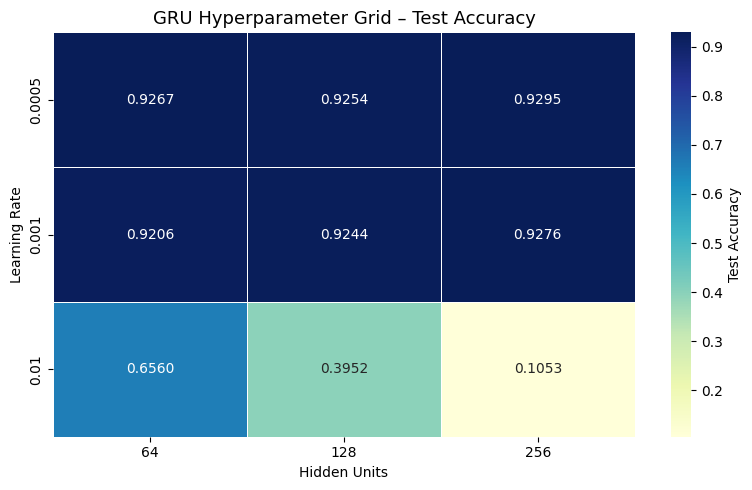

In [26]:

pivot = hp_df.pivot(index='LR', columns='Units', values='Acc')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Test Accuracy'})
plt.title('GRU Hyperparameter Grid – Test Accuracy', fontsize=13)
plt.ylabel('Learning Rate'); plt.xlabel('Hidden Units')
plt.tight_layout(); plt.show()


## 8 · Model Comparison, Evaluation Metrics & Analysis 

In [29]:
def evaluate_model(model, X_or_ds, y_true, name, is_dataset=False):
   
    if is_dataset:
        y_pred = model.predict(X_or_ds, verbose=0).argmax(axis=1)
    else:
        y_pred = model.predict(X_or_ds, verbose=0).argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    print(f"\n{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")
    print(f"  Accuracy : {acc:.4f}   Macro-F1 : {f1:.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=list(LABEL_MAP.values())))
    return {'name': name, 'acc': acc, 'f1': f1, 'preds': y_pred}

all_results = []

for model, name in [
    (resnet_ext,      'ResNet50 Extractor'),
    (vgg_ext,         'VGG16 Extractor'),
    (resnet_ft_model, 'ResNet50 Fine-tuned'),
    (embed_model,     'Patch Embed + LSTM')
]:
    y_pred = model.predict(test_ds, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro')
    print(f"\n{'─'*60}\n  {name}\n{'─'*60}")
    print(f"  Accuracy : {acc:.4f}   Macro-F1 : {f1:.4f}")
    print(classification_report(y_te, y_pred,
                                target_names=list(LABEL_MAP.values())))
    all_results.append({'name': name, 'acc': acc, 'f1': f1, 'preds': y_pred})

for name in ['SimpleRNN', 'StackedLSTM', 'StackedGRU']:
    all_results.append(
        evaluate_model(seq_results[name]['model'],
                       X_seq_te, y_seq_te, name))

all_results.append(
    evaluate_model(attn_model, X_seq_te, y_seq_te, 'LSTM + Attention'))



────────────────────────────────────────────────────────────
  ResNet50 Extractor
────────────────────────────────────────────────────────────
  Accuracy : 0.8694   Macro-F1 : 0.8310
                      precision    recall  f1-score   support

          Normal (N)       0.89      0.81      0.84       900
Supraventricular (S)       0.91      0.77      0.83       333
     Ventricular (V)       0.89      0.86      0.88       869
          Fusion (F)       0.57      0.85      0.68        96
         Unknown (Q)       0.87      0.97      0.92       965

            accuracy                           0.87      3163
           macro avg       0.83      0.85      0.83      3163
        weighted avg       0.88      0.87      0.87      3163


────────────────────────────────────────────────────────────
  VGG16 Extractor
────────────────────────────────────────────────────────────
  Accuracy : 0.9187   Macro-F1 : 0.8738
                      precision    recall  f1-score   support

          N

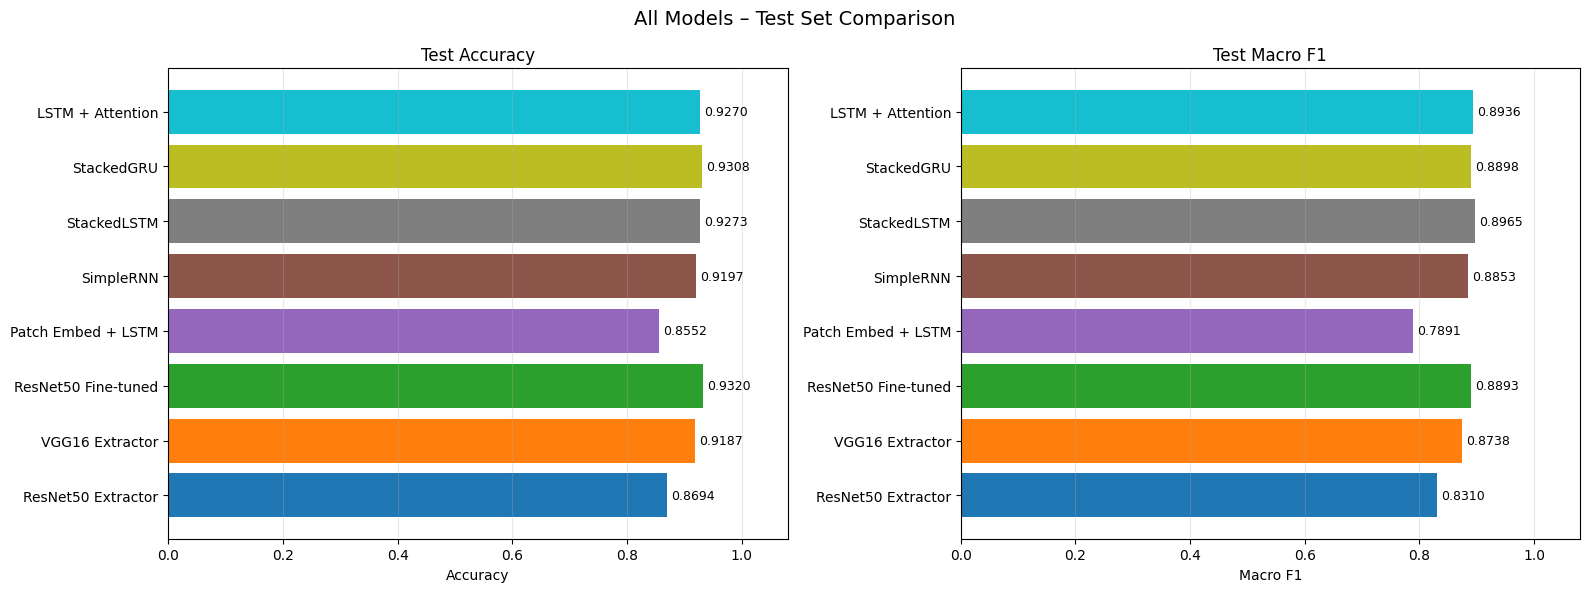


Final Summary Table:
               name      acc       f1
        StackedLSTM 0.927284 0.896458
   LSTM + Attention 0.926968 0.893640
         StackedGRU 0.930762 0.889803
ResNet50 Fine-tuned 0.932027 0.889335
          SimpleRNN 0.919696 0.885297
    VGG16 Extractor 0.918748 0.873751
 ResNet50 Extractor 0.869428 0.830978
 Patch Embed + LSTM 0.855201 0.789093


In [30]:
comp_df = pd.DataFrame([{k:v for k,v in r.items() if k!='preds'}
                         for r in all_results])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('All Models – Test Set Comparison', fontsize=14)

colors = plt.cm.tab10(np.linspace(0, 1, len(comp_df)))

for ax, col, title in [(ax1,'acc','Accuracy'), (ax2,'f1','Macro F1')]:
    bars = ax.barh(comp_df['name'], comp_df[col], color=colors)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_xlim(0, 1.08)
    ax.set_xlabel(title)
    ax.set_title(f'Test {title}')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

print("\nFinal Summary Table:")
print(comp_df[['name','acc','f1']].sort_values('f1', ascending=False)
        .to_string(index=False))


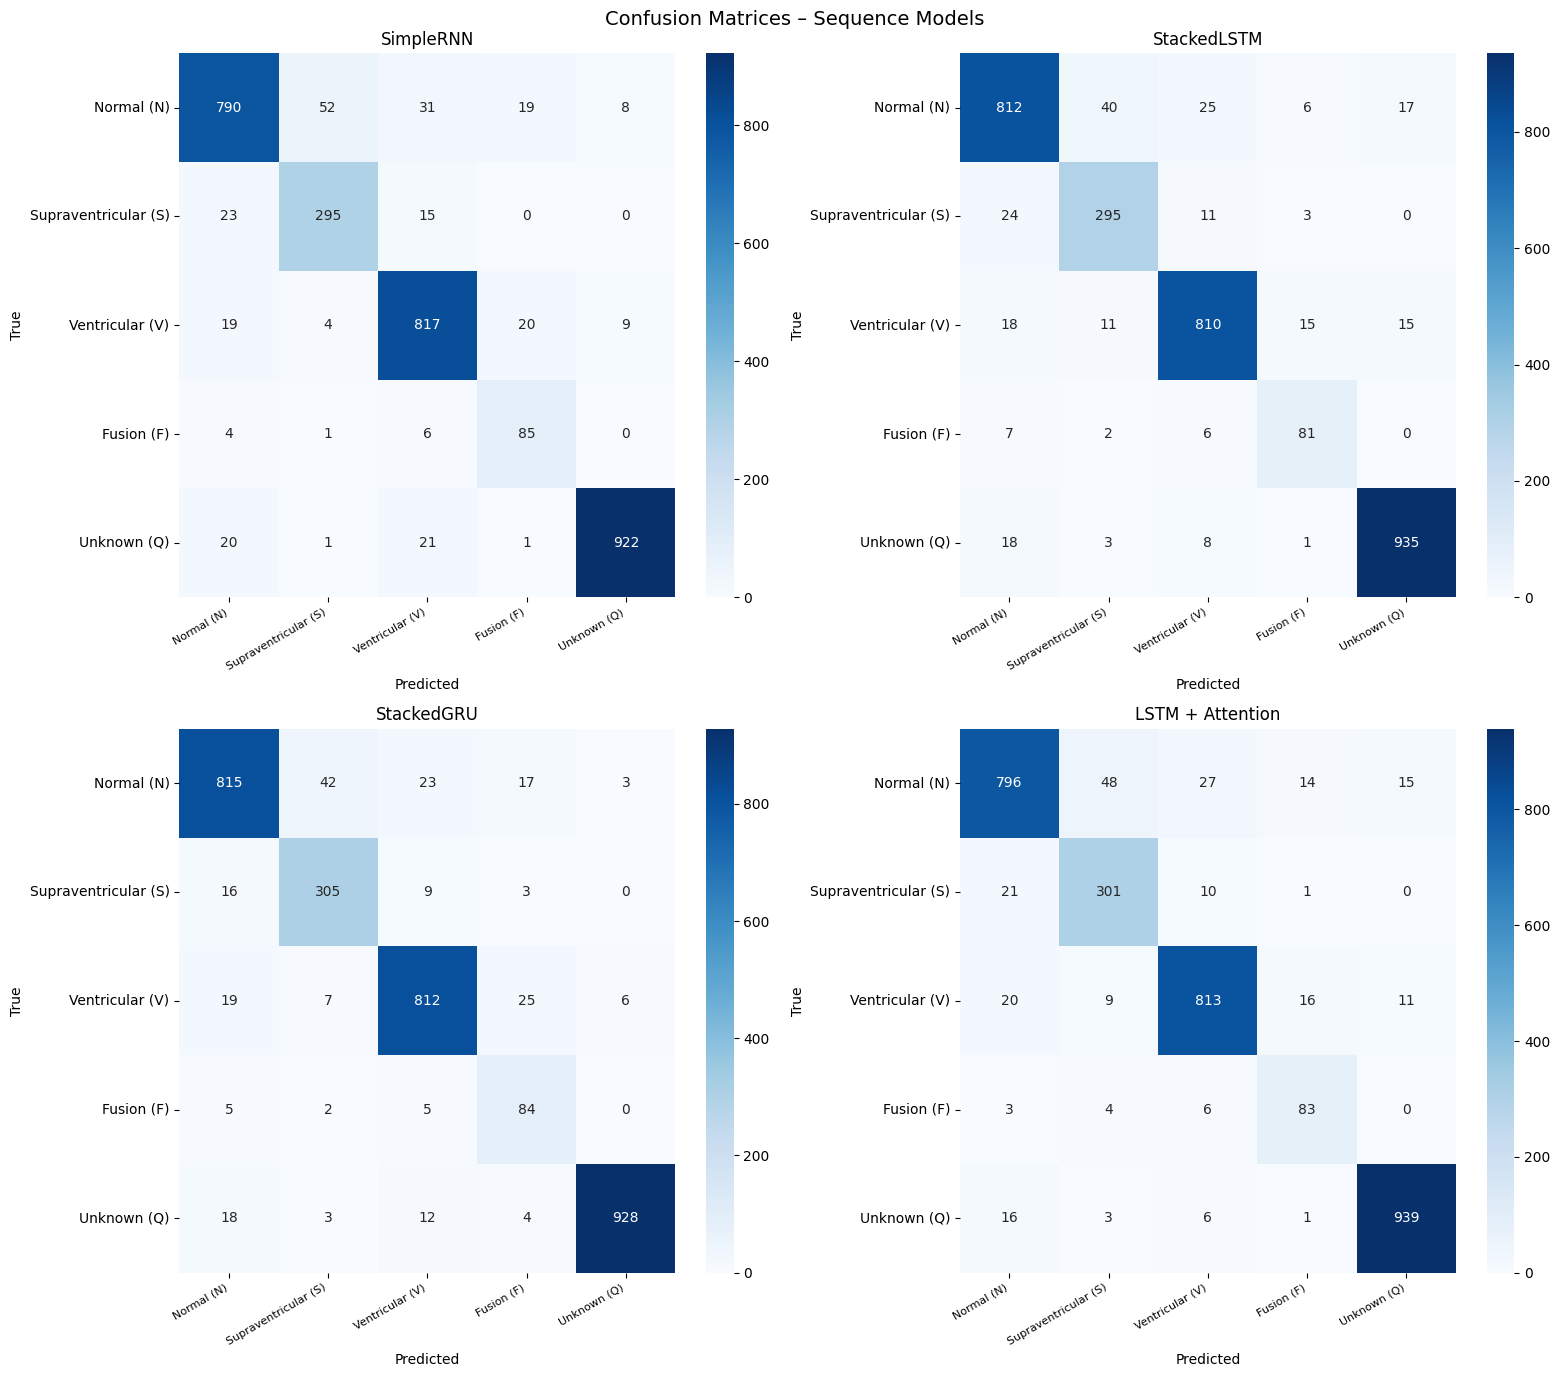

In [31]:
seq_model_names = ['SimpleRNN', 'StackedLSTM', 'StackedGRU', 'LSTM + Attention']
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Confusion Matrices – Sequence Models', fontsize=14)

for ax, name in zip(axes.flat, seq_model_names):
    preds = next(r['preds'] for r in all_results if r['name'] == name)
    cm    = confusion_matrix(y_seq_te, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=list(LABEL_MAP.values()),
                yticklabels=list(LABEL_MAP.values()))
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout(); plt.show()


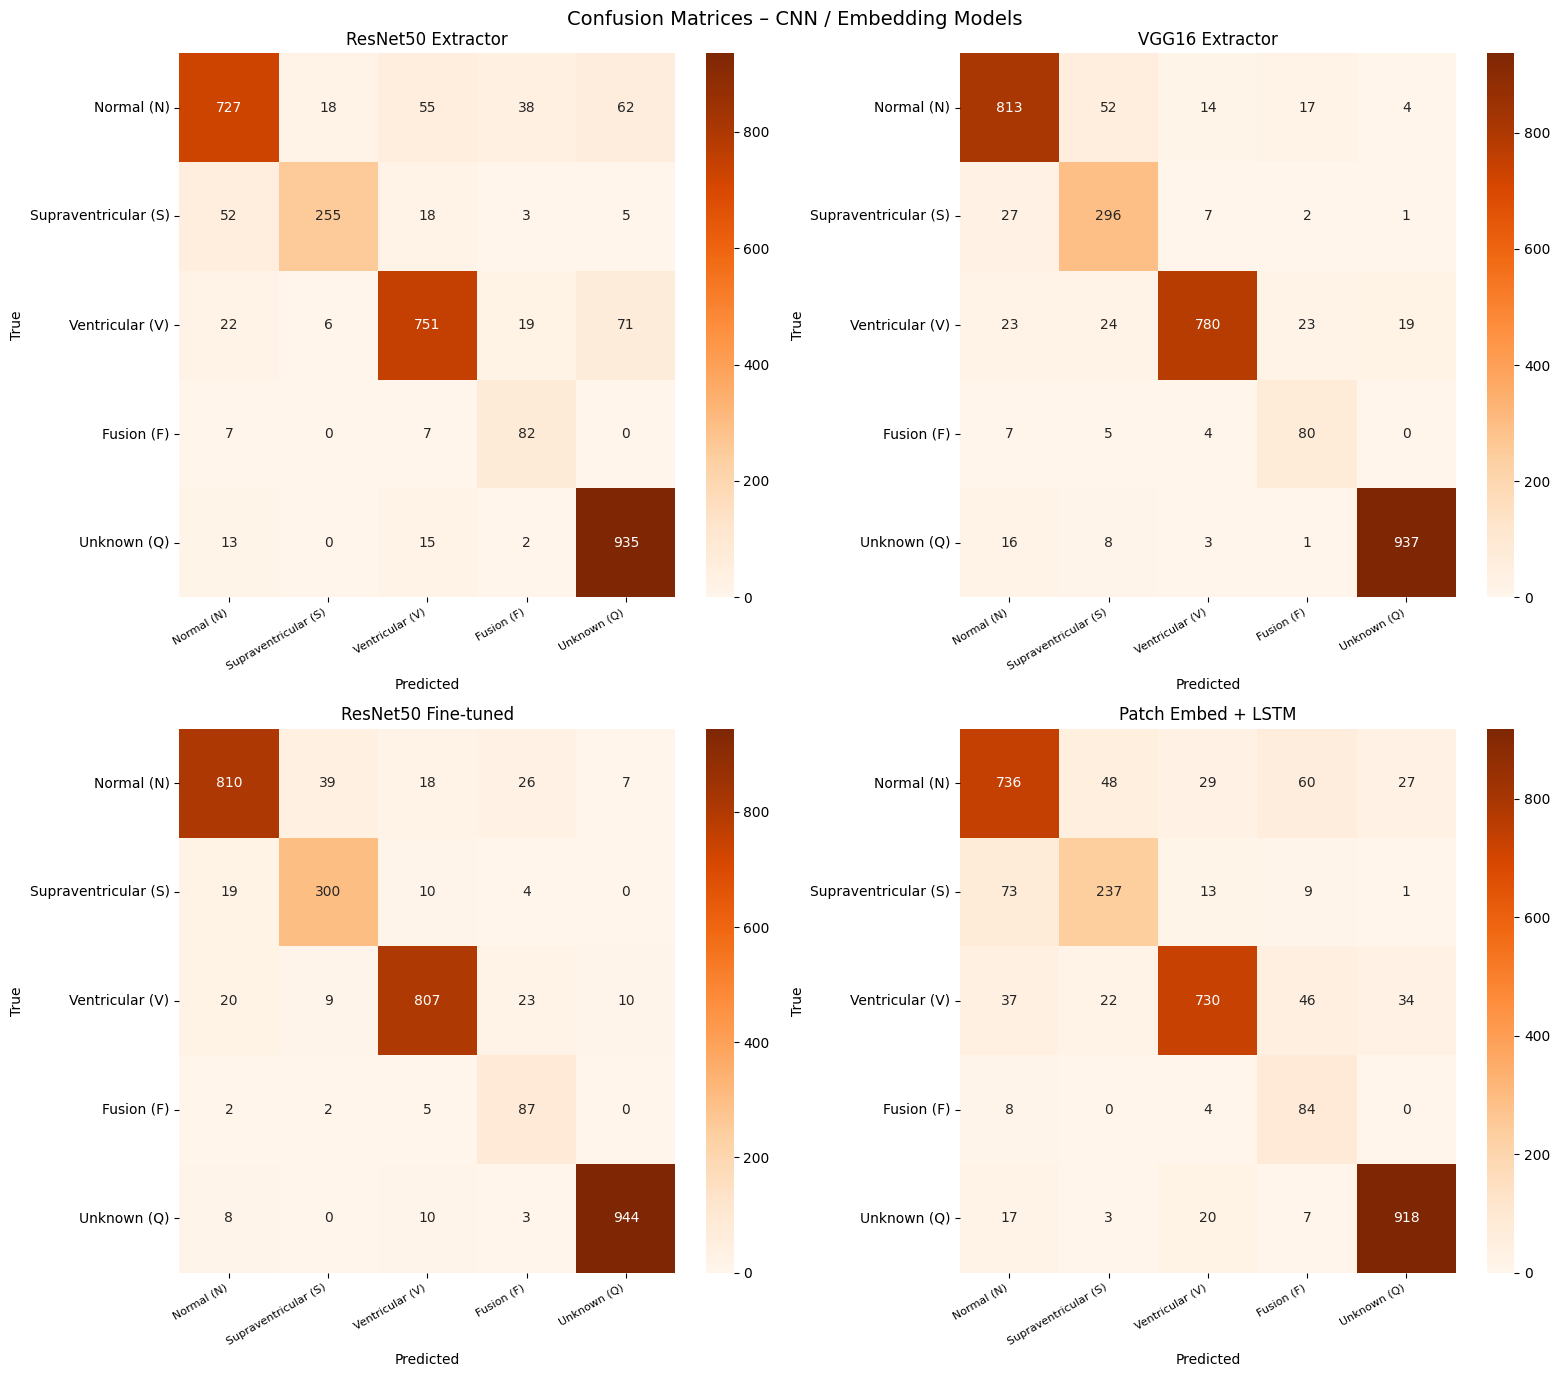

In [32]:
cnn_model_names = ['ResNet50 Extractor', 'VGG16 Extractor',
                   'ResNet50 Fine-tuned', 'Patch Embed + LSTM']
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Confusion Matrices – CNN / Embedding Models', fontsize=14)

for ax, name in zip(axes.flat, cnn_model_names):
    preds = next(r['preds'] for r in all_results if r['name'] == name)
    cm    = confusion_matrix(y_te, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=list(LABEL_MAP.values()),
                yticklabels=list(LABEL_MAP.values()))
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout(); plt.show()
